# Gemma 4 Translation Evaluation: Two-Stage vs. Standalone Benchmark
### Bidirectional English <-> Algerian Darija Model Comparison

This notebook evaluates and compares two models side-by-side:
1. **Two-Stage Model (`stage1+stage2`)**: Gemma 4 adapted on Algerian Darija text corpus in Stage 1, then fine-tuned on bidirectional translation in Stage 2 (`./gemma4-darija-en-translation-qlora`).
2. **Standalone Model (`stage2 only`)**: Gemma 4 fine-tuned directly on bidirectional translation without Stage 1 continued pre-training (`./gemma4-darija-en-translation-standalone-qlora`).

### Key Evaluation Objectives:
- **Quantify the impact of Stage 1 continued pretraining**: Does Stage 1 improve Darija generation quality, vocabulary alignment, and semantic accuracy?
- **Evaluate both directions**: English -> Algerian Darija (`en_to_ar`) and Algerian Darija -> English (`ar_to_en`).
- **Compute comprehensive MT metrics**: BLEU (SacreBLEU), chrF++, BERTScore F1, Brevity Penalty (BP), and Length Ratios on the exact same held-out test split.
- **Side-by-side comparative visualizations and tables** highlighting win rates, score deltas, and qualitative output comparisons.


In [1]:
# Environment and dependencies setup
# If running in a new environment, install required packages:
# !pip install -q sacrebleu bert-score evaluate unbabel-comet tabulate pandas matplotlib tqdm

import os
import sys
import gc
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.6.0+cu124
CUDA available: True
GPU Device: NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:
# Setup MT Evaluation Metrics
import sacrebleu

# Availability flags
USE_BERTSCORE = True
USE_COMET = False  # Set to True if unbabel-comet is installed in your environment

try:
    import bert_score
    print("✓ bert_score is available.")
except ImportError:
    print("ℹ bert_score not found. To enable: pip install bert-score")
    USE_BERTSCORE = False

try:
    import comet
    print("✓ comet is available.")
except ImportError:
    print("ℹ comet not found. To enable: pip install unbabel-comet")
    USE_COMET = False


✓ bert_score is available.
✓ comet is available.


In [3]:
# Load Base Model & LoRA Adapter Configuration
model_id = "google/gemma-4-E2B"
stage2_adapter_path = "./gemma4-darija-en-translation-qlora"
standalone_adapter_path = "./gemma4-darija-en-translation-standalone-qlora"
compute_dtype = torch.float16

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer for {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # left-padding for batched autoregressive generation

print(f"Loading 4-bit base model {model_id}...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map={"": 0} if torch.cuda.is_available() else None,
    dtype=compute_dtype,
)

def load_peft_model(adapter_path):
    """Loads a PEFT model with the specified LoRA adapter."""
    print(f"Loading LoRA adapter from {adapter_path}...")
    peft_model = PeftModel.from_pretrained(base_model, adapter_path)
    peft_model.eval()
    return peft_model

print("✓ Base model initialized and ready to mount adapters.")


Loading tokenizer for google/gemma-4-E2B...
Loading 4-bit base model google/gemma-4-E2B...


Loading weights: 100%|██████████| 1951/1951 [00:51<00:00, 38.04it/s] 


✓ Base model initialized and ready to mount adapters.


In [4]:
# Translation Prompt Templates matching fine-tuning exactly
EN_TO_AR_TEMPLATE = """ترجم الجملة التالية من الإنجليزية إلى الدارجة الجزائرية:

{sentence}

الترجمة: """

AR_TO_EN_TEMPLATE = """Translate the following Algerian Darija sentence to English:

{sentence}

Translation: """

def generate_translations_batch(model_obj, sentences, direction="en_to_ar", batch_size=8, max_new_tokens=128):
    """
    Performs batched greedy generation for reproducible and deterministic evaluation.
    """
    if direction == "en_to_ar":
        prompts = [EN_TO_AR_TEMPLATE.format(sentence=s) for s in sentences]
    elif direction == "ar_to_en":
        prompts = [AR_TO_EN_TEMPLATE.format(sentence=s) for s in sentences]
    else:
        raise ValueError("Invalid direction. Choose 'en_to_ar' or 'ar_to_en'.")

    translations = []
    for i in tqdm(range(0, len(prompts), batch_size), desc=f"Evaluating ({direction})"):
        batch_prompts = prompts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(model_obj.device)
        
        with torch.no_grad():
            outputs = model_obj.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,        # Greedy decoding for consistent deterministic evaluation
                num_beams=1,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
            
        for out in outputs:
            gen_tokens = out[inputs["input_ids"].shape[1]:]
            decoded = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
            decoded = decoded.split("\n\n")[0].strip()
            translations.append(decoded)
            
    return translations


In [5]:
# Load Cleaned Translation Dataset & Extract 5% Test Split
csv_path = "algerian_translation_50k_cleaned.csv"
df_raw = pd.read_csv(csv_path).dropna(subset=["Arabic", "English"])

df_raw["Arabic"] = df_raw["Arabic"].astype(str).str.strip()
df_raw["English"] = df_raw["English"].astype(str).str.strip()
df_clean = df_raw[(df_raw["Arabic"] != "") & (df_raw["English"] != "")].reset_index(drop=True)

# Exact 5% held-out test split with seed=42
_, df_test = train_test_split(df_clean, test_size=0.05, random_state=42)
print(f"Total held-out test pairs available: {len(df_test)}")

# EVAL_SAMPLE_SIZE: You can evaluate on a subset (e.g. 500) for fast turnaround,
# or set to None to evaluate all ~2,540 test pairs.
EVAL_SAMPLE_SIZE = 500

if EVAL_SAMPLE_SIZE is not None and len(df_test) > EVAL_SAMPLE_SIZE:
    eval_df = df_test.sample(n=EVAL_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f"Selected representative test sample of: {len(eval_df)} pairs")
else:
    eval_df = df_test.reset_index(drop=True)
    print(f"Using complete test split: {len(eval_df)} pairs")

print("\nSample test pair:")
print("  Arabic  (Darija) :", eval_df.iloc[0]["Arabic"])
print("  English (Target) :", eval_df.iloc[0]["English"])


Total held-out test pairs available: 2540
Selected representative test sample of: 500 pairs

Sample test pair:
  Arabic  (Darija) : خدمة مليحة يا خويا، بصح مالو سام؟ اديها في روحك.
  English (Target) : Good job, man, but what's wrong with Sam? Mind your own business.


In [6]:
# ====================================================================
# 1. GENERATE PREDICTIONS: Two-Stage Model (Stage 1 + Stage 2)
# ====================================================================
print("=== Loading Two-Stage (Stage 1 + Stage 2) Model ===")
model = load_peft_model(stage2_adapter_path)

sources_en = eval_df["English"].tolist()
sources_ar = eval_df["Arabic"].tolist()

print(f"[Two-Stage] Generating English -> Darija ({len(sources_en)} sentences)...")
eval_df["pred_ar_stage2"] = generate_translations_batch(
    model, sources_en, direction="en_to_ar", batch_size=8, max_new_tokens=128
)

print(f"[Two-Stage] Generating Darija -> English ({len(sources_ar)} sentences)...")
eval_df["pred_en_stage2"] = generate_translations_batch(
    model, sources_ar, direction="ar_to_en", batch_size=8, max_new_tokens=128
)

# Clean up model from GPU memory before loading standalone adapter
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("✓ Two-Stage predictions complete.")


=== Loading Two-Stage (Stage 1 + Stage 2) Model ===
Loading LoRA adapter from ./gemma4-darija-en-translation-qlora...
[Two-Stage] Generating English -> Darija (500 sentences)...


Evaluating (en_to_ar): 100%|██████████| 63/63 [53:46<00:00, 51.22s/it] 


[Two-Stage] Generating Darija -> English (500 sentences)...


Evaluating (ar_to_en): 100%|██████████| 63/63 [55:00<00:00, 52.39s/it] 


✓ Two-Stage predictions complete.


In [7]:
# ====================================================================
# 2. GENERATE PREDICTIONS: Standalone Model (Stage 2 Only)
# ====================================================================
print("=== Loading Standalone (Stage 2 Only) Model ===")
model = load_peft_model(standalone_adapter_path)

print(f"[Standalone] Generating English -> Darija ({len(sources_en)} sentences)...")
eval_df["pred_ar_standalone"] = generate_translations_batch(
    model, sources_en, direction="en_to_ar", batch_size=8, max_new_tokens=128
)

print(f"[Standalone] Generating Darija -> English ({len(sources_ar)} sentences)...")
eval_df["pred_en_standalone"] = generate_translations_batch(
    model, sources_ar, direction="ar_to_en", batch_size=8, max_new_tokens=128
)

# Clean up model from GPU memory
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("✓ Standalone predictions complete.")


=== Loading Standalone (Stage 2 Only) Model ===
Loading LoRA adapter from ./gemma4-darija-en-translation-standalone-qlora...
[Standalone] Generating English -> Darija (500 sentences)...


Evaluating (en_to_ar): 100%|██████████| 63/63 [54:39<00:00, 52.06s/it]


[Standalone] Generating Darija -> English (500 sentences)...


Evaluating (ar_to_en): 100%|██████████| 63/63 [54:09<00:00, 51.58s/it] 


✓ Standalone predictions complete.


In [8]:
# Metric Computation Functions
def compute_translation_metrics(hypotheses, references, sources=None, lang_pair="en-ar"):
    """
    Computes BLEU, chrF++, BERTScore, and COMET.
    """
    results = {}
    
    # 1. SacreBLEU
    tokenize_opt = "intl" if "ar" in lang_pair else "13a"
    bleu_calc = sacrebleu.corpus_bleu(hypotheses, [references], tokenize=tokenize_opt)
    results["BLEU"] = round(bleu_calc.score, 2)
    results["BLEU_bp"] = round(bleu_calc.bp, 4)
    results["sys_len"] = bleu_calc.sys_len
    results["ref_len"] = bleu_calc.ref_len
    results["len_ratio"] = round(bleu_calc.sys_len / max(1, bleu_calc.ref_len), 3)
    
    # 2. chrF++ (word_order=2 for chrF++)
    chrf_calc = sacrebleu.corpus_chrf(hypotheses, [references], word_order=2)
    results["chrF++"] = round(chrf_calc.score, 2)
    
    # Sentence-level chrF++
    sent_chrf = [
        sacrebleu.sentence_chrf(hyp, [ref], word_order=2).score
        for hyp, ref in zip(hypotheses, references)
    ]
    results["sentence_chrF++"] = sent_chrf
    
    # 3. BERTScore
    if USE_BERTSCORE:
        try:
            from bert_score import score as bert_scorer
            target_lang = "ar" if lang_pair.endswith("ar") else "en"
            scorer_device = "cuda:0" if torch.cuda.is_available() else "cpu"
            P, R, F1 = bert_scorer(
                hypotheses,
                references,
                lang=target_lang,
                verbose=False,
                device=scorer_device
            )
            results["BERTScore_Precision"] = round(P.mean().item() * 100, 2)
            results["BERTScore_Recall"] = round(R.mean().item() * 100, 2)
            results["BERTScore_F1"] = round(F1.mean().item() * 100, 2)
            results["sentence_BERTScore_F1"] = [score.item() * 100 for score in F1]
        except Exception as e:
            print(f"Notice: BERTScore skipped: {e}")
            
    # 4. COMET
    if USE_COMET and sources is not None:
        try:
            from comet import download_model, load_from_checkpoint
            comet_path = download_model("Unbabel/wmt22-comet-da")
            comet_model = load_from_checkpoint(comet_path)
            comet_data = [
                {"src": s, "mt": h, "ref": r}
                for s, h, r in zip(sources, hypotheses, references)
            ]
            comet_res = comet_model.predict(comet_data, batch_size=8, gpus=1 if torch.cuda.is_available() else 0)
            results["COMET"] = round(comet_res.system_score * 100, 2)
            results["sentence_COMET"] = comet_res.scores
        except Exception as e:
            print(f"Notice: COMET skipped: {e}")
            
    return results


In [9]:
# ====================================================================
# Run Metric Computations for Both Models
# ====================================================================
print("=== Computing Metrics: Two-Stage (Stage 1 + Stage 2) ===")
print("-> English to Algerian Darija (en_to_ar)...")
metrics_stage2_en_to_ar = compute_translation_metrics(
    hypotheses=eval_df["pred_ar_stage2"].tolist(),
    references=eval_df["Arabic"].tolist(),
    sources=eval_df["English"].tolist(),
    lang_pair="en-ar"
)
print("-> Algerian Darija to English (ar_to_en)...")
metrics_stage2_ar_to_en = compute_translation_metrics(
    hypotheses=eval_df["pred_en_stage2"].tolist(),
    references=eval_df["English"].tolist(),
    sources=eval_df["Arabic"].tolist(),
    lang_pair="ar-en"
)

print("\n=== Computing Metrics: Standalone (Stage 2 Only) ===")
print("-> English to Algerian Darija (en_to_ar)...")
metrics_standalone_en_to_ar = compute_translation_metrics(
    hypotheses=eval_df["pred_ar_standalone"].tolist(),
    references=eval_df["Arabic"].tolist(),
    sources=eval_df["English"].tolist(),
    lang_pair="en-ar"
)
print("-> Algerian Darija to English (ar_to_en)...")
metrics_standalone_ar_to_en = compute_translation_metrics(
    hypotheses=eval_df["pred_en_standalone"].tolist(),
    references=eval_df["English"].tolist(),
    sources=eval_df["Arabic"].tolist(),
    lang_pair="ar-en"
)


=== Computing Metrics: Two-Stage (Stage 1 + Stage 2) ===
-> English to Algerian Darija (en_to_ar)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2074.48it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Notice: BERTScore skipped: BertTokenizer has no attribute build_inputs_with_special_tokens
-> Algerian Darija to English (ar_to_en)...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2226.29it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Notice: BERTScore skipped: RobertaTokenizer has no attribute build_inputs_with_special_tokens

=== Computing Metrics: Standalone (Stage 2 Only) ===
-> English to Algerian Darija (en_to_ar)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2501.18it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-> Algerian Darija to English (ar_to_en)...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2458.37it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
# Build Comprehensive Comparative Summary Tables (Two-Stage vs. Standalone)
def create_comparison_df(metric_keys, labels, m_stage2, m_standalone):
    rows = []
    for key, label in zip(metric_keys, labels):
        v_s2 = m_stage2.get(key, "N/A")
        v_sta = m_standalone.get(key, "N/A")
        if isinstance(v_s2, (int, float)) and isinstance(v_sta, (int, float)):
            delta = round(v_s2 - v_sta, 3)
            delta_str = f"{'+' if delta > 0 else ''}{delta}"
        else:
            delta_str = "-"
        rows.append({
            "Metric": label,
            "Two-Stage (Stage 1 + 2)": v_s2,
            "Standalone (Stage 2)": v_sta,
            "Delta (Stage 1 Gain)": delta_str
        })
    return pd.DataFrame(rows)

core_keys = ["BLEU", "chrF++", "BLEU_bp", "len_ratio"]
core_labels = ["BLEU (sacrebleu)", "chrF++ (word_order=2)", "Brevity Penalty (BP)", "Length Ratio (Sys/Ref)"]

if "BERTScore_F1" in metrics_stage2_en_to_ar and "BERTScore_F1" in metrics_standalone_en_to_ar:
    core_keys.extend(["BERTScore_F1", "BERTScore_Precision", "BERTScore_Recall"])
    core_labels.extend(["BERTScore F1 (%)", "BERTScore Precision (%)", "BERTScore Recall (%)"])

if "COMET" in metrics_stage2_en_to_ar and "COMET" in metrics_standalone_en_to_ar:
    core_keys.append("COMET")
    core_labels.append("COMET Score")

df_compare_en_ar = create_comparison_df(core_keys, core_labels, metrics_stage2_en_to_ar, metrics_standalone_en_to_ar)
df_compare_ar_en = create_comparison_df(core_keys, core_labels, metrics_stage2_ar_to_en, metrics_standalone_ar_to_en)

print("=" * 75)
print("  DIRECTION 1: English -> Algerian Darija (en_to_ar) COMPARISON")
print("=" * 75)
print(df_compare_en_ar.to_string(index=False))
print("\n" + "=" * 75)
print("  DIRECTION 2: Algerian Darija -> English (ar_to_en) COMPARISON")
print("=" * 75)
print(df_compare_ar_en.to_string(index=False))
print("=" * 75)


  DIRECTION 1: English -> Algerian Darija (en_to_ar) COMPARISON
                Metric  Two-Stage (Stage 1 + 2)  Standalone (Stage 2) Delta (Stage 1 Gain)
      BLEU (sacrebleu)                  25.6400               25.9900                -0.35
 chrF++ (word_order=2)                  45.3300               45.7000                -0.37
  Brevity Penalty (BP)                   0.7122                0.7134               -0.001
Length Ratio (Sys/Ref)                   0.7470                0.7480               -0.001

  DIRECTION 2: Algerian Darija -> English (ar_to_en) COMPARISON
                Metric  Two-Stage (Stage 1 + 2)  Standalone (Stage 2) Delta (Stage 1 Gain)
      BLEU (sacrebleu)                  41.9100               42.2500                -0.34
 chrF++ (word_order=2)                  54.8200               55.1800                -0.36
  Brevity Penalty (BP)                   0.7456                0.7395               +0.006
Length Ratio (Sys/Ref)                   0.7730     

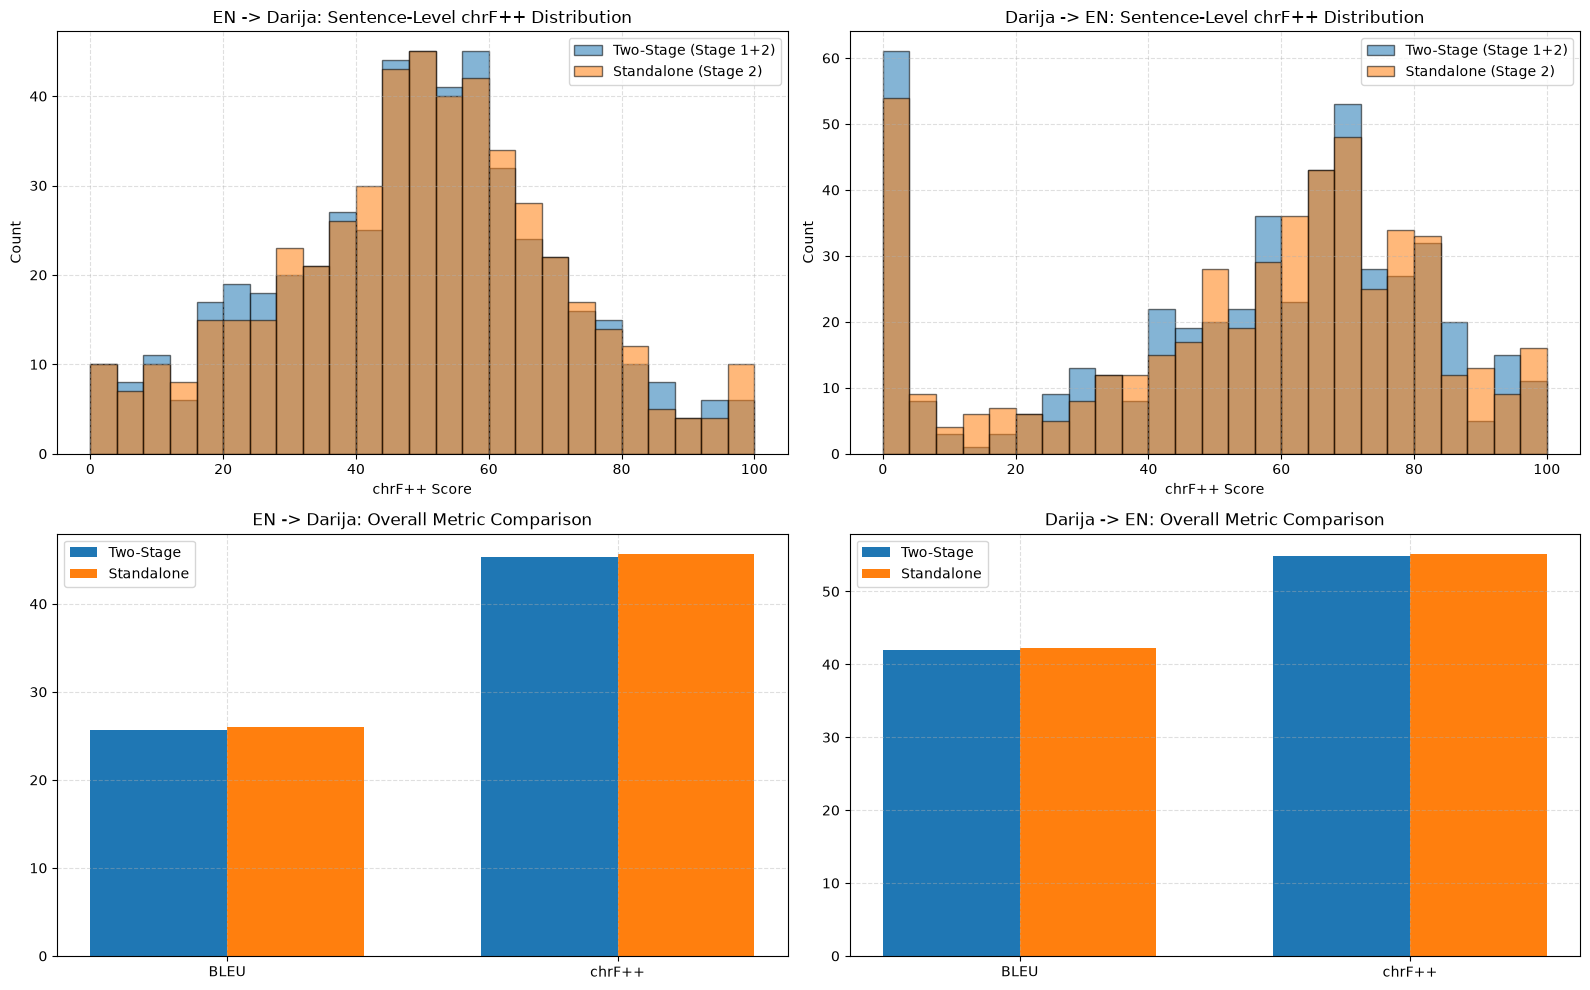

In [11]:
# Comparative Visualizations: Two-Stage vs. Standalone
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. EN -> AR chrF++ Distribution
axes[0, 0].hist(metrics_stage2_en_to_ar["sentence_chrF++"], bins=25, alpha=0.55, label="Two-Stage (Stage 1+2)", color="#1f77b4", edgecolor="black")
axes[0, 0].hist(metrics_standalone_en_to_ar["sentence_chrF++"], bins=25, alpha=0.55, label="Standalone (Stage 2)", color="#ff7f0e", edgecolor="black")
axes[0, 0].set_title("EN -> Darija: Sentence-Level chrF++ Distribution")
axes[0, 0].set_xlabel("chrF++ Score")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.4)

# 2. AR -> EN chrF++ Distribution
axes[0, 1].hist(metrics_stage2_ar_to_en["sentence_chrF++"], bins=25, alpha=0.55, label="Two-Stage (Stage 1+2)", color="#1f77b4", edgecolor="black")
axes[0, 1].hist(metrics_standalone_ar_to_en["sentence_chrF++"], bins=25, alpha=0.55, label="Standalone (Stage 2)", color="#ff7f0e", edgecolor="black")
axes[0, 1].set_title("Darija -> EN: Sentence-Level chrF++ Distribution")
axes[0, 1].set_xlabel("chrF++ Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.4)

# 3. Bar Chart Comparison for Core Metrics (EN -> AR)
metrics_to_plot = ["BLEU", "chrF++"]
if "BERTScore_F1" in metrics_stage2_en_to_ar and "BERTScore_F1" in metrics_standalone_en_to_ar:
    metrics_to_plot.append("BERTScore_F1")

x = np.arange(len(metrics_to_plot))
width = 0.35

vals_s2_en_ar = [metrics_stage2_en_to_ar[m] for m in metrics_to_plot]
vals_sta_en_ar = [metrics_standalone_en_to_ar[m] for m in metrics_to_plot]

axes[1, 0].bar(x - width/2, vals_s2_en_ar, width, label="Two-Stage", color="#1f77b4")
axes[1, 0].bar(x + width/2, vals_sta_en_ar, width, label="Standalone", color="#ff7f0e")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_to_plot)
axes[1, 0].set_title("EN -> Darija: Overall Metric Comparison")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.4)

# 4. Bar Chart Comparison for Core Metrics (AR -> EN)
vals_s2_ar_en = [metrics_stage2_ar_to_en[m] for m in metrics_to_plot]
vals_sta_ar_en = [metrics_standalone_ar_to_en[m] for m in metrics_to_plot]

axes[1, 1].bar(x - width/2, vals_s2_ar_en, width, label="Two-Stage", color="#1f77b4")
axes[1, 1].bar(x + width/2, vals_sta_ar_en, width, label="Standalone", color="#ff7f0e")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_to_plot)
axes[1, 1].set_title("Darija -> EN: Overall Metric Comparison")
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [12]:
# Qualitative Comparison: Side-by-Side Predictions & Sentence Deltas
eval_df["chrf_en_to_ar_stage2"] = metrics_stage2_en_to_ar["sentence_chrF++"]
eval_df["chrf_en_to_ar_standalone"] = metrics_standalone_en_to_ar["sentence_chrF++"]
eval_df["chrf_gain_stage1"] = eval_df["chrf_en_to_ar_stage2"] - eval_df["chrf_en_to_ar_standalone"]

stage1_wins = (eval_df["chrf_gain_stage1"] > 0).sum()
standalone_wins = (eval_df["chrf_gain_stage1"] < 0).sum()
ties = (eval_df["chrf_gain_stage1"] == 0).sum()
print(f"Sentence-Level chrF++ Win Rates (EN -> Darija):")
print(f"  Two-Stage Wins: {stage1_wins} ({stage1_wins/len(eval_df)*100:.1f}%)")
print(f"  Standalone Wins: {standalone_wins} ({standalone_wins/len(eval_df)*100:.1f}%)")
print(f"  Ties:            {ties} ({ties/len(eval_df)*100:.1f}%)")

print("\n" + "=" * 80)
print("Examples where Stage 1 (Two-Stage) outperformed Standalone most (EN -> Darija):")
print("=" * 80)
for _, row in eval_df.sort_values(by="chrf_gain_stage1", ascending=False).head(3).iterrows():
    print(f"Source (EN)       : {row['English']}")
    print(f"Reference (AR)    : {row['Arabic']}")
    print(f"Two-Stage (S1+2)  : {row['pred_ar_stage2']} (chrF++: {row['chrf_en_to_ar_stage2']:.2f})")
    print(f"Standalone (S2)   : {row['pred_ar_standalone']} (chrF++: {row['chrf_en_to_ar_standalone']:.2f})")
    print(f"Stage 1 chrF Gain : +{row['chrf_gain_stage1']:.2f}\n")

print("=" * 80)
print("Examples where Standalone performed better or different (EN -> Darija):")
print("=" * 80)
for _, row in eval_df.sort_values(by="chrf_gain_stage1", ascending=True).head(3).iterrows():
    print(f"Source (EN)       : {row['English']}")
    print(f"Reference (AR)    : {row['Arabic']}")
    print(f"Two-Stage (S1+2)  : {row['pred_ar_stage2']} (chrF++: {row['chrf_en_to_ar_stage2']:.2f})")
    print(f"Standalone (S2)   : {row['pred_ar_standalone']} (chrF++: {row['chrf_en_to_ar_standalone']:.2f})")
    print(f"Stage 1 chrF Gain : {row['chrf_gain_stage1']:.2f}\n")


Sentence-Level chrF++ Win Rates (EN -> Darija):
  Two-Stage Wins: 184 (36.8%)
  Standalone Wins: 200 (40.0%)
  Ties:            116 (23.2%)

Examples where Stage 1 (Two-Stage) outperformed Standalone most (EN -> Darija):
Source (EN)       : Mohamed's Center
Reference (AR)    : مركز محمد
Two-Stage (S1+2)  : ڨاع مركز محمد (chrF++: 89.07)
Standalone (S2)   : ڨاع (chrF++: 0.00)
Stage 1 chrF Gain : +89.07

Source (EN)       : Happy with his courage
Reference (AR)    : فرحان بشجاعتو
Two-Stage (S1+2)  : ڨاع فرحان بشجاعتو (chrF++: 92.53)
Standalone (S2)   : ڨاع راضي على شجاعتو (chrF++: 26.02)
Stage 1 chrF Gain : +66.51

Source (EN)       : We will play
Reference (AR)    : رانا رايحين نلعبوا
Two-Stage (S1+2)  : ڨاع رانا رايحين نلعبو (chrF++: 81.67)
Standalone (S2)   : ڨاع راح نلعبو (chrF++: 18.07)
Stage 1 chrF Gain : +63.60

Examples where Standalone performed better or different (EN -> Darija):
Source (EN)       : Oh
Reference (AR)    : آه
Two-Stage (S1+2)  : ڨاع (chrF++: 0.00)
Standalone (S2)

In [13]:
# Save Comparative Predictions and Metrics to File
eval_csv_file = "comparative_evaluation_results.csv"
eval_df.to_csv(eval_csv_file, index=False, encoding="utf-8-sig")
print(f"✓ Saved comprehensive comparative predictions table to {eval_csv_file}")

summary_json_file = "comparative_evaluation_summary.json"
metrics_export = {
    "sample_size": len(eval_df),
    "two_stage_model": {
        "adapter_path": stage2_adapter_path,
        "english_to_darija": {k: v for k, v in metrics_stage2_en_to_ar.items() if not k.startswith("sentence_")},
        "darija_to_english": {k: v for k, v in metrics_stage2_ar_to_en.items() if not k.startswith("sentence_")},
    },
    "standalone_model": {
        "adapter_path": standalone_adapter_path,
        "english_to_darija": {k: v for k, v in metrics_standalone_en_to_ar.items() if not k.startswith("sentence_")},
        "darija_to_english": {k: v for k, v in metrics_standalone_ar_to_en.items() if not k.startswith("sentence_")},
    }
}

with open(summary_json_file, "w", encoding="utf-8") as f:
    json.dump(metrics_export, f, indent=4, ensure_ascii=False)
print(f"✓ Saved comparative summary metrics to {summary_json_file}")


✓ Saved comprehensive comparative predictions table to comparative_evaluation_results.csv
✓ Saved comparative summary metrics to comparative_evaluation_summary.json
